# Fine-Tune Pretrained Commutative CNN Classifier

Load the pretrained commutative CNN encoder and fine-tune the full network on the current labeled action dataset.

In [1]:
%load_ext autoreload
%autoreload 2

from dataclasses import asdict
from pathlib import Path

import pandas as pd

from src.ml import (
    CommutativeCNNClassifier,
    CommutativeCNNConfig,
    LossWeightConfig,
    OptimizationConfig,
    display_experiment_summary,
    display_holdout_evaluation,
    fit_estimator_on_experiment,
    persist_experiment_artifacts,
    plot_training_history,
    prepare_multitask_experiment_data,
)
from src.dataset_config import load_current_dataset_artifact_path
from src.tensor_utils import build_tensor_embedding_2d, load_labeled_tensor_dataset, plot_tensor_embedding_2d

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)

In [2]:
# User inputs

dataset_artifact_path = load_current_dataset_artifact_path()
pretrained_encoder_path = Path("artifacts/pretrained_commutative_cnn/encoder_state.pt")
experiment_output_dir = Path("artifacts/nb13C_commutative_cnn_full_finetune")
persist_artifacts = True

holdout_fraction = 0.25
validation_fraction_within_train = 0.20
train_num_random_rotations = 6
rotation_range_degrees = 12.0

model_config = CommutativeCNNConfig(
    spatial_conv_channels=(6, 8),
    spatial_kernel_size_z=(1, 1),
    spatial_kernel_size_xy=(5, 3),
    spatial_stride_z=(1, 1),
    spatial_stride_xy=(1, 1),
    spatial_pool_kernel_z=(1, 1),
    spatial_pool_kernel_xy=(2, 2),
    spatial_pool_stride_z=(1, 1),
    spatial_pool_stride_xy=(2, 2),
    temporal_st_channels=(12,),
    temporal_st_kernel_sizes=(3,),
    temporal_ts_channels=(8,),
    temporal_ts_kernel_sizes=(5,),
    spatial_agg_channels=(12,),
    spatial_agg_kernel_size_z=(3,),
    spatial_agg_kernel_size_xy=(3,),
    spatial_agg_stride_z=(1,),
    spatial_agg_stride_xy=(1,),
    spatial_agg_pool_kernel_z=(1,),
    spatial_agg_pool_kernel_xy=(2,),
    spatial_agg_pool_stride_z=(1,),
    spatial_agg_pool_stride_xy=(2,),
    patch_size_z=1,
    patch_size_xy=16,
    embedding_dim=8,
    num_prototypes=8,
    dropout=0.5,
)
optimization_config = OptimizationConfig(
    batch_size=8,
    epochs=100,
    learning_rate=5e-5,
    weight_decay=3e-3,
    early_stopping_patience=8,
    early_stopping_min_delta=0.0,
    scheduler_patience=2,
    scheduler_factor=0.7,
    scheduler_min_lr=1e-6,
    validation_split=0.0,
    random_state=0,
    standardize=True,
    device=None,
    verbose=True,
)
loss_weight_config = LossWeightConfig(
    action_weight=1.0,
    compound_weight=0.05,
    concentration_weight=0.05,
    consistency_weight=0.05,
    feature_weight=0.0,
    prototype_temperature=0.1,
)

In [3]:
dataset = load_labeled_tensor_dataset(dataset_artifact_path)
experiment = prepare_multitask_experiment_data(
    dataset,
    holdout_fraction=holdout_fraction,
    validation_fraction_within_train=validation_fraction_within_train,
    train_num_random_rotations=train_num_random_rotations,
    rotation_range_degrees=rotation_range_degrees,
    random_state=optimization_config.random_state,
)
display_experiment_summary(experiment)

,split,n_samples
0,train_augmented,1155
1,train_base,165
2,val,42
3,holdout,70


,mechanism_of_action,compound,concentration_band,n_samples
0,mAChR_Agonist_NonSelective,Pilocarpine,high,56
1,AChE_Inhibitor_Reversible,Phenserine,high,49
2,AChE_Inhibitor_Reversible,Donepezil,control,42
3,AChE_Inhibitor_Reversible,Galantamine,control,42
4,NMDAR_Activation,Cis-ACPD,high,42
5,GABAAR_Antagonist,Bemegride,control,42
6,GABAAR_Antagonist,Gabazine,control,42
7,NMDAR_Activation,N-methyl-D-aspartate,high,35
8,NMDAR_Activation,Cis-ACPD,control,35
9,GABAAR_Antagonist,Gabazine,mid,35


cols:
    ep=epoch
    lr=learning_rate
    eta=estimated_time_remaining
    trL=train_loss
    trA=train_action_loss
    trCC=train_commutative_consistency_loss
    trFA=train_feature_alignment_loss
    trCo=train_compound_loss
    trCn=train_concentration_loss
    vaL=val_loss
    vaA=val_action_loss
    vaCC=val_commutative_consistency_loss
    vaFA=val_feature_alignment_loss
    vaCo=val_compound_loss
    vaCn=val_concentration_loss
     ep       lr       eta |      trL      trA     trCC     trFA     trCo     trCn |      vaL      vaA     vaCC     vaFA     vaCo     vaCn
001/100 5.00e-05   2:09:21 |   1.9000   1.6233   1.8776   0.0649   2.5116   1.1465 |   1.8967   1.6204   1.8606   0.0372   2.5546   1.1127
002/100 5.00e-05   2:08:13 |   1.8863   1.6091   1.8956   0.0803   2.5006   1.1474 |   1.8863   1.6106   1.8556   0.0374   2.5443   1.1135
003/100 5.00e-05   2:08:36 |   1.8725   1.5958   1.9007   0.1031   2.4862   1.1471 |   1.8725   1.5962   1.8746   0.0628   2.5374   1.1156
004

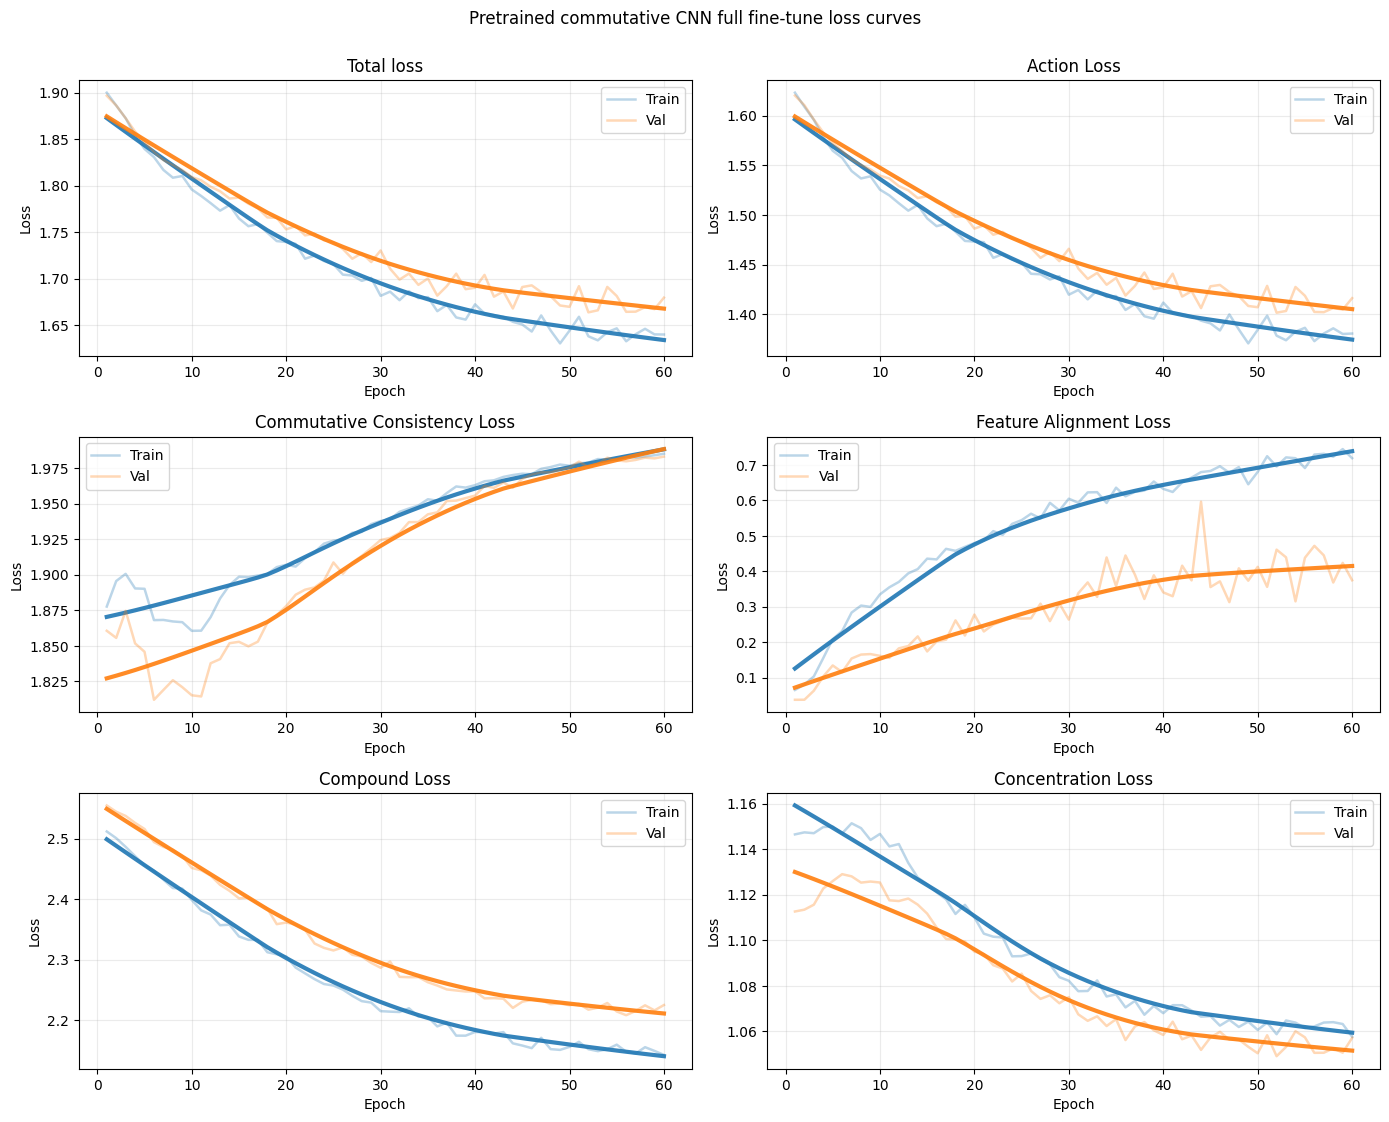

In [4]:
model = CommutativeCNNClassifier(
    model_config=model_config,
    optimization_config=optimization_config,
    loss_weight_config=loss_weight_config,
    pretrained_state_path=pretrained_encoder_path,
    freeze_backbone=False,
)
fit_estimator_on_experiment(model, experiment)
plot_training_history(model, title="Pretrained commutative CNN full fine-tune loss curves", loess_frac=0.6);


## Holdout report: action


,precision,recall,f1-score,support
class,,,,
Water,0.396226,0.875000,0.545455,24.0
GABAAR_Antagonist,0.666667,0.166667,0.266667,12.0
NMDAR_Activation,0.571429,0.800000,0.666667,10.0
AChE_Inhibitor_Reversible,0.000000,0.000000,0.000000,12.0
mAChR_Agonist_NonSelective,0.000000,0.000000,0.000000,12.0


,value
accuracy,0.442857
macro_precision,0.326864
macro_recall,0.368333
macro_f1,0.295758
weighted_precision,0.331767
weighted_recall,0.442857
weighted_f1,0.327965
n_samples,70.000000
roc_auc_ovr_macro,0.699055
average_precision_macro,0.419489


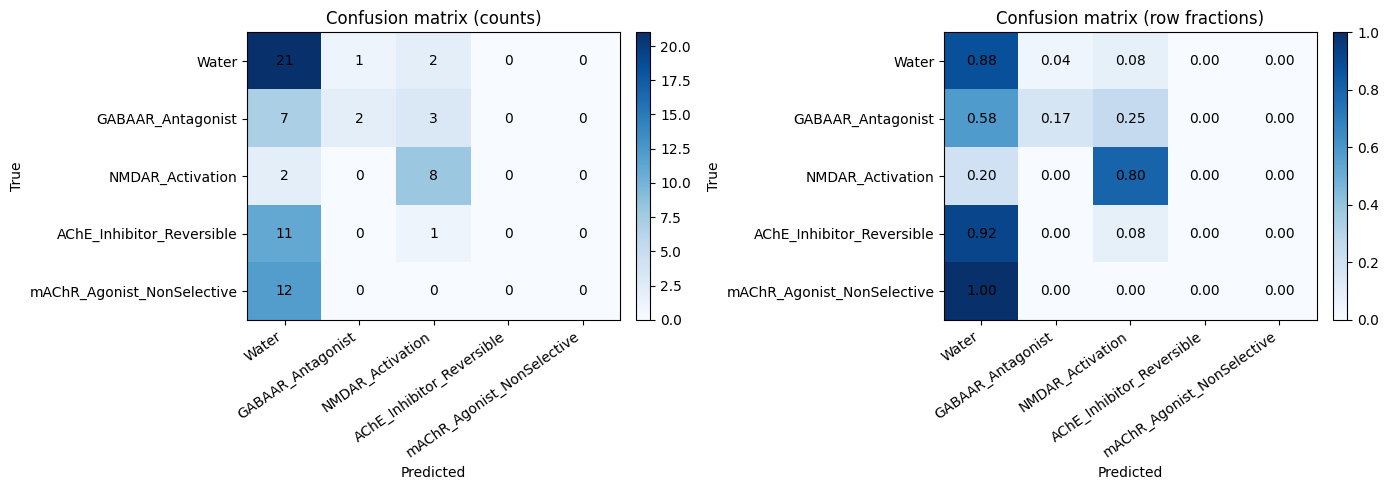


## Holdout report: compound


,precision,recall,f1-score,support
class,,,,
Control,0.388889,0.875000,0.538462,24.0
Bemegride,0.000000,0.000000,0.000000,5.0
Bicuculline,0.133333,0.666667,0.222222,3.0
Gabazine,0.000000,0.000000,0.000000,4.0
(RS)-(Tetrazol-5-yl)glycine,0.000000,0.000000,0.000000,3.0
Cis-ACPD,0.000000,0.000000,0.000000,3.0
N-methyl-D-aspartate,0.000000,0.000000,0.000000,4.0
Donepezil,0.000000,0.000000,0.000000,6.0
Galantamine,0.000000,0.000000,0.000000,5.0


,value
accuracy,0.328571
macro_precision,0.040171
macro_recall,0.118590
macro_f1,0.058514
weighted_precision,0.139048
weighted_recall,0.328571
weighted_f1,0.194139
n_samples,70.000000
roc_auc_ovr_macro,0.634513
average_precision_macro,0.195904


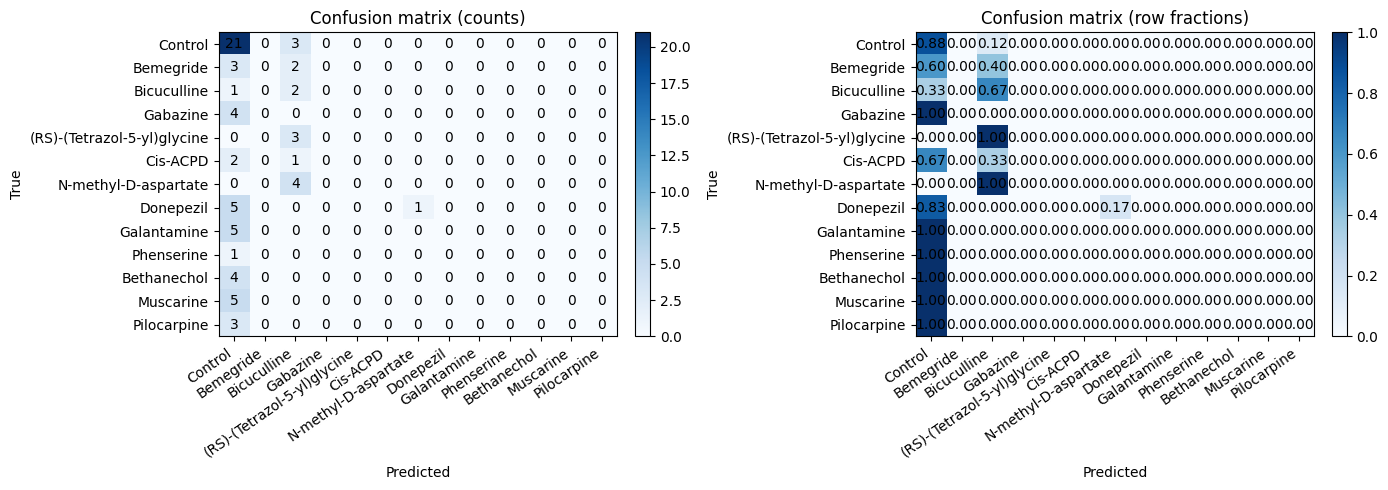


## Holdout report: concentration


,precision,recall,f1-score,support
class,,,,
control,0.411765,0.875000,0.56,24.0
high,0.588235,0.434783,0.50,23.0
mid,0.000000,0.000000,0.00,23.0


,value
accuracy,0.442857
macro_precision,0.333333
macro_recall,0.436594
macro_f1,0.353333
weighted_precision,0.334454
weighted_recall,0.442857
weighted_f1,0.356286
n_samples,70.000000
roc_auc_ovr_macro,0.614689
average_precision_macro,0.448762


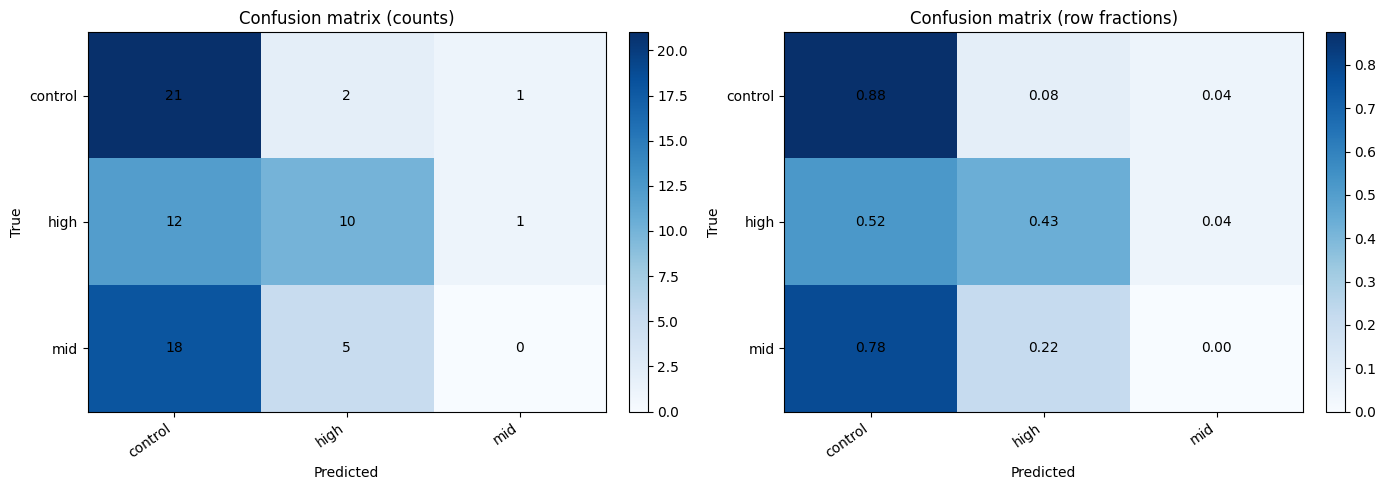

In [5]:
holdout_evaluation = display_holdout_evaluation(model, experiment)

(<Figure size 1550x1050 with 1 Axes>,
 <Axes: title={'center': 'Holdout embedding projection by action'}, xlabel='Component 1', ylabel='Component 2'>)

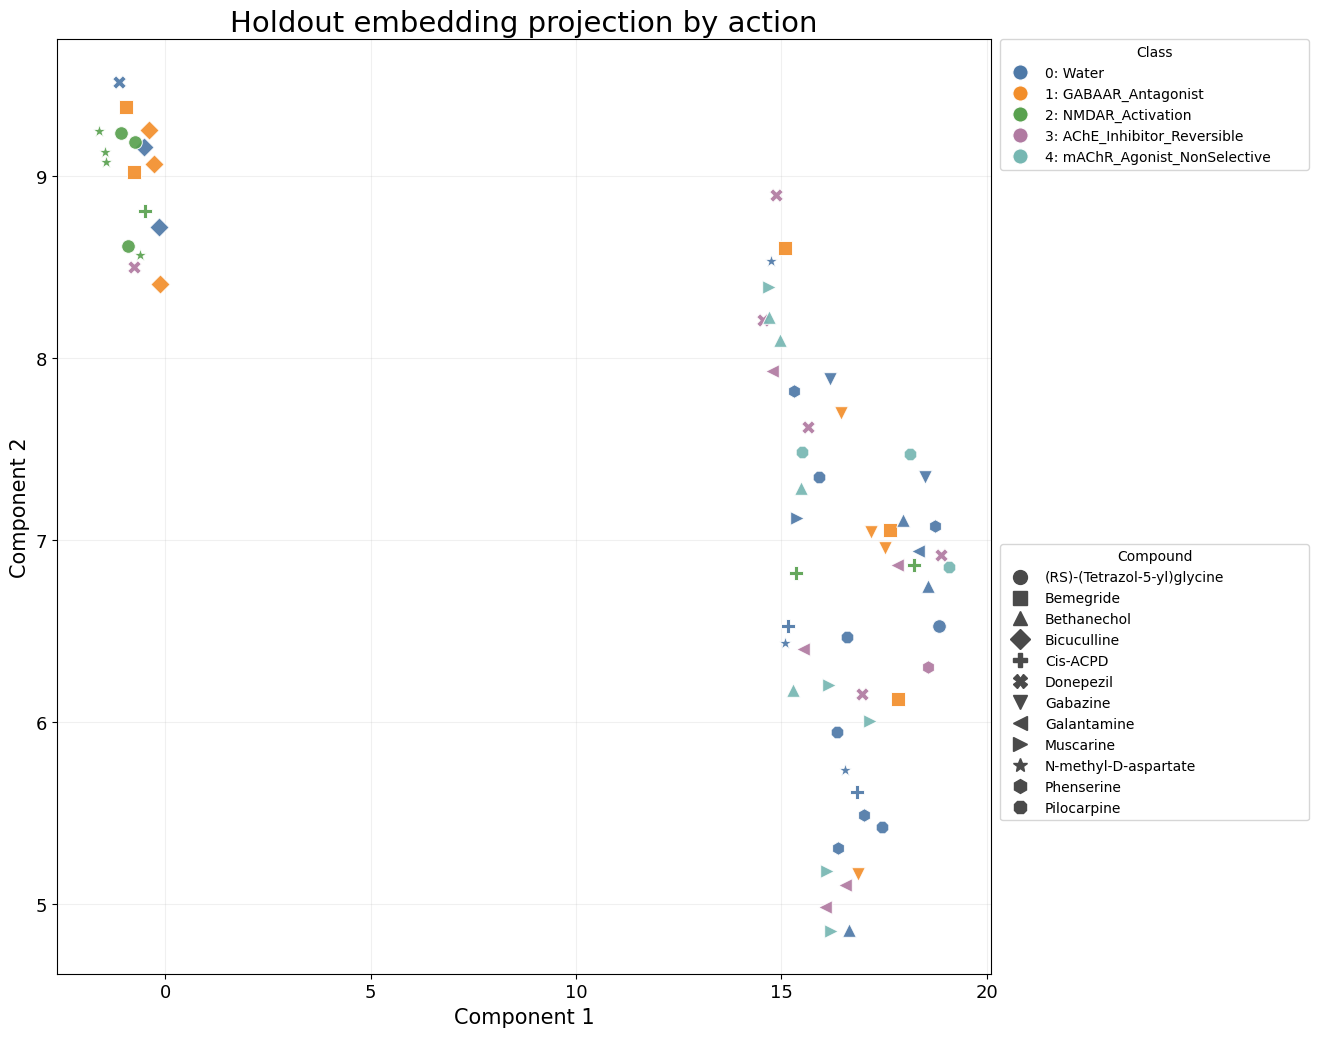

In [6]:
holdout_embedding_projection = build_tensor_embedding_2d(
    model.transform(experiment.splits.X_holdout),
    experiment.y_true_holdout["action"],
    label_map=experiment.label_maps["action"],
    metadata=experiment.splits.metadata_holdout,
    method="umap",
    random_state=optimization_config.random_state,
)
plot_tensor_embedding_2d(
    holdout_embedding_projection,
    title="Holdout embedding projection by action",
    marker_column="compound",
)

In [7]:
run_config = {
    "dataset_artifact_path": dataset_artifact_path,
    "pretrained_encoder_path": pretrained_encoder_path,
    "freeze_backbone": False,
    "holdout_fraction": holdout_fraction,
    "validation_fraction_within_train": validation_fraction_within_train,
    "train_num_random_rotations": train_num_random_rotations,
    "rotation_range_degrees": rotation_range_degrees,
    "model_config": asdict(model_config),
    "optimization_config": asdict(optimization_config),
    "loss_weight_config": asdict(loss_weight_config),
}
if persist_artifacts:
    experiment_artifacts = persist_experiment_artifacts(
        output_dir=experiment_output_dir,
        estimator=model,
        reports=holdout_evaluation.reports,
        config=run_config,
    )
    experiment_artifacts